In [1]:
from random import sample

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import scipy.optimize as opt
import seaborn as sns
import math as mt
from IPython.display import display, Math
from numpy.ma.extras import hstack
from skimage.io import imread, imsave


Уравнение линейной регрессии

In [3]:
W = np.array([1, 5, 2])
ksi = np.array([1, 0, 1])
eta = np.array([0, 1, 1])

psi = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
])

F = psi.T @ psi
F_inv = np.linalg.inv(F)
beta = F_inv @ psi.T @ W
print(beta)






[-0.33333333  3.66666667]


Уравнение ridge регрессии

best lambda = 1.5151515151515151
beta ridge = [0.31220183 1.90256327]


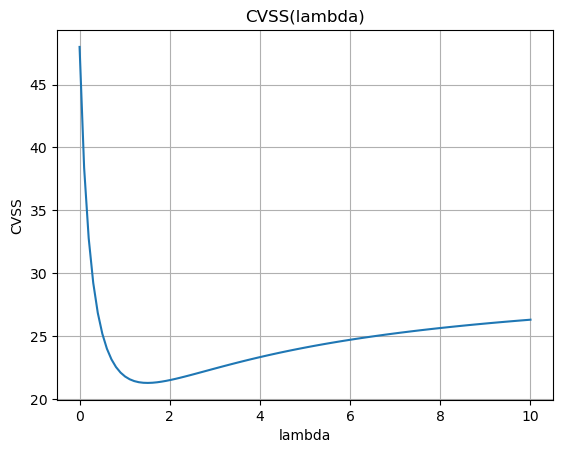

In [ ]:
def CVSS_ridge(psi_train, Y_train, psi_test, Y_test, lam):
    p = psi_train.shape[1]    
    F_train = psi_train.T @ psi_train
    E = np.eye(p)    
    betta_hat = np.linalg.inv(F_train + lam * E) @ psi_train.T @ Y_train    
    Y_hat_test = psi_test @ betta_hat    
    return np.sum((Y_test - Y_hat_test) ** 2)

lams = np.linspace(0, 10, 100)
CVSS_vals = []
for lam in lams:
    CVSS_total = 0    
    for i in range(len(W)):
        psi_train = np.delete(psi, i, axis=0)
        Y_train = np.delete(W, i)        
        psi_test = psi[i].reshape(1, -1)
        Y_test = np.array([W[i]])        
        CVSS_total += CVSS_ridge(psi_train, Y_train, psi_test, Y_test, lam)    
    CVSS_vals.append(CVSS_total)
CVSS_vals = np.array(CVSS_vals)

best_index = np.argmin(CVSS_vals)
best_lam = lams[best_index]
E = np.eye(psi.shape[1])
beta_ridge = np.linalg.inv(psi.T @ psi + best_lam * E) @ psi.T @ W
print("best lambda =", best_lam)
print("beta ridge =", beta_ridge)
plt.plot(lams, CVSS_vals)
plt.xlabel("lambda")
plt.ylabel("CVSS")
plt.title("CVSS(lambda)")
plt.grid()
plt.show()


CVSS_MIN =  25.999999978682563
lamb0 =  6.0


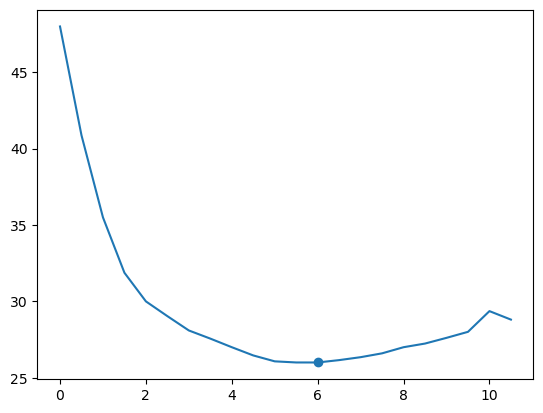

In [18]:
CVSS = np.array([])
lamb = np.arange(0, 11, 0.5)

CVSS_MIN = -1
lamb0_lasso = 0

my_vect = np.array([1, 0, 1, 0, 1, 5, 1, 1, 2]).reshape(3, 3).T
Y = my_vect[2, :].reshape(3, 1)
Psi_tran = my_vect[:2, :].copy()
F = np.dot(Psi_tran, Psi_tran.T)
F_rever = np.linalg.inv(F)
betta_sample = np.dot(np.dot(F_rever, Psi_tran), Y)

def L(betta, Y_new, Psi_new, lamb_i):
    return sum([(Y_new[i] - Psi_new[i, 0] * betta[0] - Psi_new[i, 1] * betta[1])**2 for i in range(2)]) + lamb_i * (abs(betta[0]) + abs(betta[1]))

for lamb_i in lamb:
    CVSS_i = np.array([])
    for j in range(3):
        match j:
            case 0:
                Y_new = my_vect[2, 1:]
                Psi_new = my_vect[:2, 1:].T

                solution = opt.minimize(L, x0=betta_sample[:, 0], args=(Y_new, Psi_new, lamb_i))
                CVSS_j = (np.dot(my_vect[:2, 0].T, solution.x) - my_vect[2, 0])**2
                CVSS_i = np.append(CVSS_i, CVSS_j)
            case 1:
                Y_new = my_vect[2, :3:2]
                Psi_new = my_vect[:2, :3:2].T

                solution = opt.minimize(L, x0=betta_sample[:, 0], args=(Y_new, Psi_new, lamb_i))
                CVSS_j = (np.dot(my_vect[:2, 1].T, solution.x) - my_vect[2, 1])**2
                CVSS_i = np.append(CVSS_i, CVSS_j)
            case 2:
                Y_new = my_vect[2, :2]
                Psi_new = my_vect[:2, :2].T

                solution = opt.minimize(L, x0=betta_sample[:, 0], args=(Y_new, Psi_new, lamb_i))
                CVSS_j = (np.dot(my_vect[:2, 2].T, solution.x) - my_vect[2, 2])**2
                CVSS_i = np.append(CVSS_i, CVSS_j)

    CVSS = np.append(CVSS, sum(CVSS_i))

    if (CVSS_MIN != -1 and sum(CVSS_i) < CVSS_MIN) or (CVSS_MIN == -1):
        CVSS_MIN = sum(CVSS_i)
        lamb0_lasso = lamb_i

plt.plot(lamb, CVSS)
plt.scatter(lamb0_lasso, CVSS_MIN)
print("CVSS_MIN = ", CVSS_MIN)
print("lamb0 = ", lamb0_lasso)